# JAX Eccentric Model with pyTDI

This notebook shows the standalone `eGB-multi` package workflow:

1. Build an eccentric compact-binary source.
2. Compare the switchable source-physics modes.
3. Compare fixed and Peters-Mathews source evolution modes.
4. Generate JAX six-link responses.
5. Route the links through pyTDI to Michelson `X/Y/Z` and convert to `A/E/T`.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from egb_jax_eccentric import (
    EccentricBinaryParams,
    aet_from_xyz,
    eccentric_complex_strain,
    eccentric_links_jax,
    eccentric_xyz_jax,
    lisa_orbit,
    precompute_jax_link_geometry,
)

plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True})

## Source and LISA State

The internal `lisa_orbit` helper gives a lightweight analytic LISA orbit. For production comparisons, replace it with `state_from_lisaorbits(default_lisaorbits(...), times)`.

In [2]:
duration = 20_000.0
samples = 1024
times = np.linspace(0.0, duration, samples, endpoint=False)
state = lisa_orbit(times)
geometry = precompute_jax_link_geometry(state)

source = EccentricBinaryParams(
    mean_motion=np.pi * 1.0e-4,
    eccentricity=0.08,
    m1_solar=0.6,
    m2_solar=0.4,
    beta=0.2,
    lambda_=0.4,
    psi=0.3,
    inclination=0.8,
    phi0=0.2,
)

source

EccentricBinaryParams(mean_motion=0.0003141592653589793, eccentricity=0.08, m1_solar=0.6, m2_solar=0.4, distance_m=3.085677581491367e+19, inclination=0.8, beta=0.2, lambda_=0.4, psi=0.3, phi0=0.2, t0=0.0, fdot=0.0)

## Switchable Source Physics

`physics_mode` can be `newtonian`, `1pn_no_periastron`, or `1pn_periastron`. The historical `1pn` spelling is still accepted as an alias. The JAX exact-link path accepts the same switch.

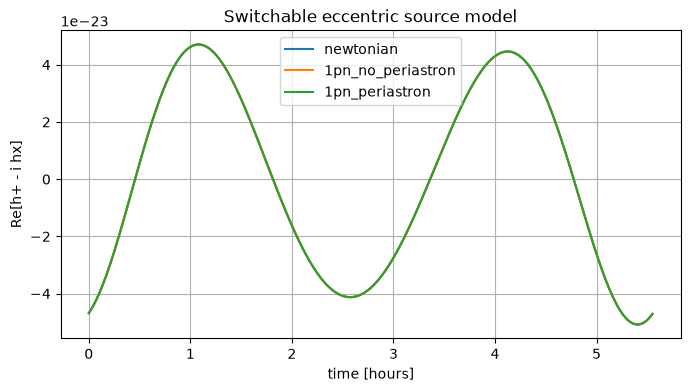

In [3]:
physics_modes = ["newtonian", "1pn_no_periastron", "1pn_periastron"]
strains = {
    mode: eccentric_complex_strain(source, times, physics_mode=mode)
    for mode in physics_modes
}

for mode, strain in strains.items():
    plt.plot(times / 3600.0, np.real(strain), label=mode)
plt.xlabel("time [hours]")
plt.ylabel("Re[h+ - i hx]")
plt.legend()
plt.title("Switchable eccentric source model")
plt.show()

## Fixed vs Peters-Mathews Evolution

`evolution_mode` is separate from `physics_mode`. Use `fixed` to hold source parameters fixed, or `peters_mathews`/`pm` to evolve radial mean motion, eccentricity, and mean anomaly in the NumPy source generator.

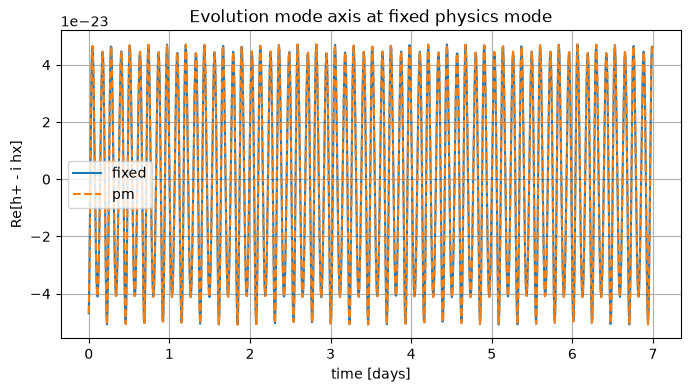

In [4]:
evolution_times = np.linspace(0.0, 7.0 * 24.0 * 3600.0, samples, endpoint=False)
fixed_strain = eccentric_complex_strain(
    source,
    evolution_times,
    physics_mode="1pn_periastron",
    evolution_mode="fixed",
)
pm_strain = eccentric_complex_strain(
    source,
    evolution_times,
    physics_mode="1pn_periastron",
    evolution_mode="pm",
)

plt.plot(evolution_times / 86400.0, np.real(fixed_strain), label="fixed")
plt.plot(evolution_times / 86400.0, np.real(pm_strain), label="pm", linestyle="--")
plt.xlabel("time [days]")
plt.ylabel("Re[h+ - i hx]")
plt.legend()
plt.title("Evolution mode axis at fixed physics mode")
plt.show()

## JAX Links and pyTDI `X/Y/Z`

`eccentric_links_jax` returns six pyTDI-labelled one-way GW links. `eccentric_xyz_jax` is the convenience path that immediately routes those links through pyTDI.

In [5]:
links = eccentric_links_jax(source, geometry, batch_size=1, physics_mode="1pn_periastron")
print({label: value.shape for label, value in links.items()})

xyz = eccentric_xyz_jax(
    state,
    source,
    geometry=geometry,
    batch_size=1,
    physics_mode="1pn_periastron",
    measurement_order=3,
    delay_order=3,
)
print({channel: value.shape for channel, value in xyz.items()})

E0907 17:33:36.111750 2362211 cuda_executor.cc:1182] [0] Failed to allocate device memory of 33.32GiB (35775315968 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0907 17:33:36.112060 2362211 cuda_executor.cc:1182] [0] Failed to allocate device memory of 29.99GiB (32197783552 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0907 17:33:36.112262 2362211 cuda_executor.cc:1182] [0] Failed to allocate device memory of 26.99GiB (28978003968 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0907 17:33:36.112459 2362211 cuda_executor.cc:1182] [0] Failed to allocate device memory of 24.29GiB (26080202752 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0907 17:33:36.112652 2362211 cuda_executor.cc:1182] [0] Failed to allocate device memory of 21.86GiB (23472181248 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0907 17:33:36.112847 2362211 cuda_executor.cc:1182] [0] Failed to allocate

{'21': (1024,), '32': (1024,), '13': (1024,), '31': (1024,), '23': (1024,), '12': (1024,)}
{'X': (1024,), 'Y': (1024,), 'Z': (1024,)}


/scratch/e1498138/anaconda3/envs/egb-multi/lib/python3.11/site-packages/pytdi/dsp.py:72: ComplexWarning: Casting complex values to real discards the imaginary part
  return data.astype(float)


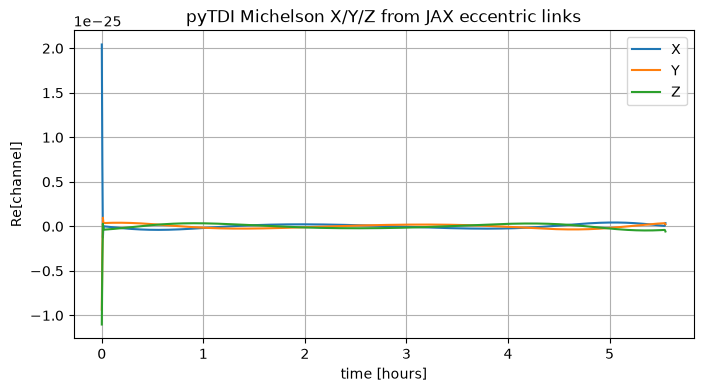

In [6]:
for channel, series in xyz.items():
    plt.plot(times / 3600.0, np.real(series), label=channel)
plt.xlabel("time [hours]")
plt.ylabel("Re[channel]")
plt.legend()
plt.title("pyTDI Michelson X/Y/Z from JAX eccentric links")
plt.show()

## `A/E/T` Conversion

A: rms=7.925837e-27
E: rms=4.559185e-27
T: rms=1.329297e-29


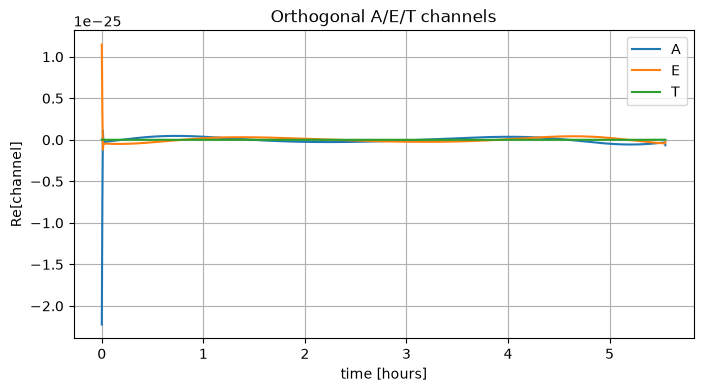

In [7]:
aet = aet_from_xyz(xyz)

for channel, series in aet.items():
    rms = np.sqrt(np.mean(np.abs(series) ** 2))
    print(f"{channel}: rms={rms:.6e}")

for channel, series in aet.items():
    plt.plot(times / 3600.0, np.real(series), label=channel)
plt.xlabel("time [hours]")
plt.ylabel("Re[channel]")
plt.legend()
plt.title("Orthogonal A/E/T channels")
plt.show()